
| <h1> **Hands-on Activity 10.1** </h1> | <h1> **Data Analysis using Python** </h1> |
|--- | --- |
Name: | Cabrera, Gabriel A.<br>
Course and Section: |  CPE 311-CPE22S3<br>
Instructor: | Eng. Neal Barton James Matira
Date Performed: | April 07, 2026
Date Submitted: | April 07, 2026


<hr>

# About the dataset

This dataset contains various attributes of students, including their socio-economic factors and academic performance. We will analyze the correlation between these factors and the students' final grades in mathematics.

## Extract
In this phase, we import all the needed python library to extract the needed data as well as visualize the dataset. After that, we load the dataset from the CSV file.

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [16]:
raw_df = pd.read_csv('student-mat.csv', sep = None, engine = 'python')
print(f"Shape: {raw_df.shape}")
print("\nColumns:")
print(raw_df.columns.tolist())
raw_df.head()

Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Transform

In this phase, we clean and preprocess the data: handle missing values, data types, and prepare for analysis.

In [19]:
processed_df = raw_df.copy()

for col in processed_df.columns:
    if processed_df[col].isna().any():
        if pd.api.types.is_numeric_dtype(processed_df[col]):
            processed_df[col] = processed_df[col].fillna(processed_df[col].median())
        else:
            mode = processed_df[col].mode(dropna=True)
            processed_df[col] = processed_df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

processed_df["Final_Grade_Avg"] = processed_df[["G1", "G2", "G3"]].mean(axis=1)

categorical_cols = processed_df.select_dtypes(include=["object", "string"]).columns.tolist()
encoded_df = pd.get_dummies(processed_df, columns=categorical_cols, drop_first=True)

print(f"Processed shape before encoding: {processed_df.shape}")
print(f"Shape after encoding: {encoded_df.shape}")

Processed shape before encoding: (395, 34)
Shape after encoding: (395, 43)


For this part, I made a new column called "Final_Grade_Avg" which is the average of the three grade columns (G1, G2, G3). This will be the target variable for our correlation analysis. I also handled missing values by filling numeric columns with their median and categorical columns with their mode. Finally, I encoded the categorical variables using one-hot encoding to prepare the data for correlation analysis.

## Load
In this phase, we perform exploratory data analysis to gain insights from the data.

In [ ]:
desc_cols = ["studytime", "failures", "absences", "Final_Grade_Avg"]
desc_table = encoded_df[desc_cols].describe().T
print("Descriptive summary for Quality Education indicators:")
display(desc_table)

Descriptive summary for Quality Education indicators:


,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.000000,1.000000,2.000000,2.000000,4.000000
failures,395.0,0.334177,0.743651,0.000000,0.000000,0.000000,0.000000,3.000000
absences,395.0,5.708861,8.003096,0.000000,0.000000,4.000000,8.000000,75.000000
Final_Grade_Avg,395.0,10.679325,3.696786,1.333333,8.333333,10.666667,13.333333,19.333333


I tried generating a table based on the basic factors that can affect a student's final average.

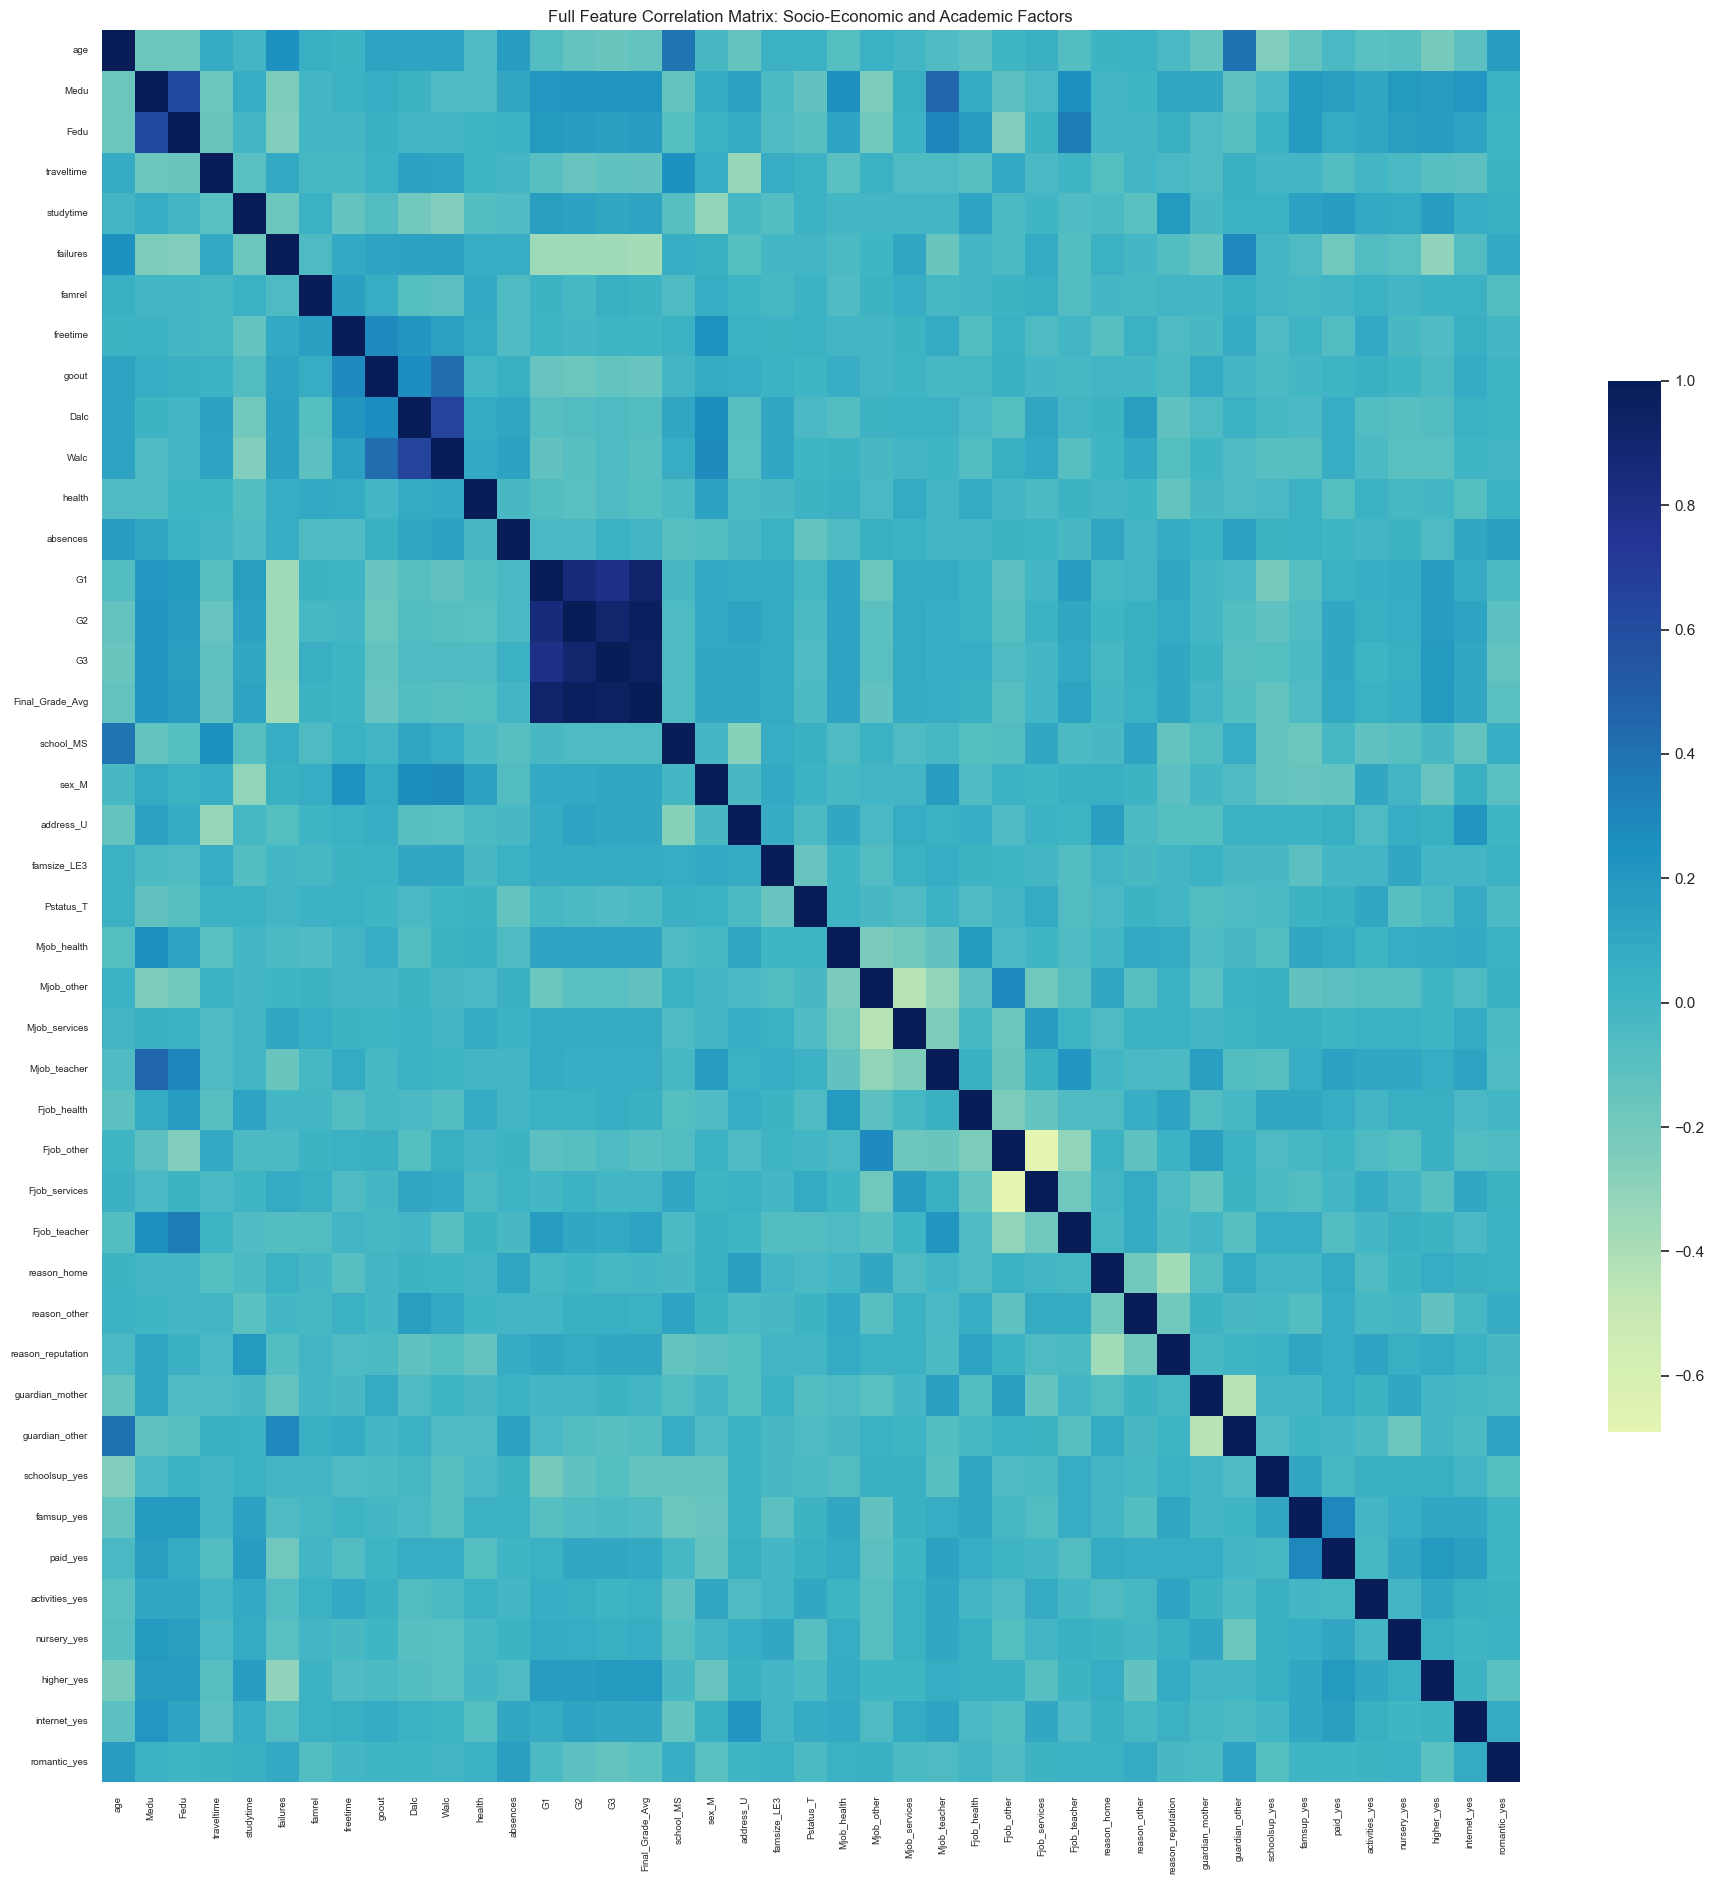

In [29]:
corr_matrix_all = encoded_df.corr(numeric_only=True)
n_features = corr_matrix_all.shape[0]
fig_side = max(12, min(26, int(n_features * 0.45)))

plt.figure(figsize=(fig_side, fig_side))
sns.heatmap(corr_matrix_all, cmap="YlGnBu", center=0, square=False, cbar_kws={"shrink": 0.6})
plt.title("Full Feature Correlation Matrix: Socio-Economic and Academic Factors")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

At first, I tried to generate a heatmap for the whole dataset to see which features are most correlated so I can focus on the storytelling for those. Doing this is very helpful for me but would not be usable for actual presentations since it's very large and overloads the viewer with information.

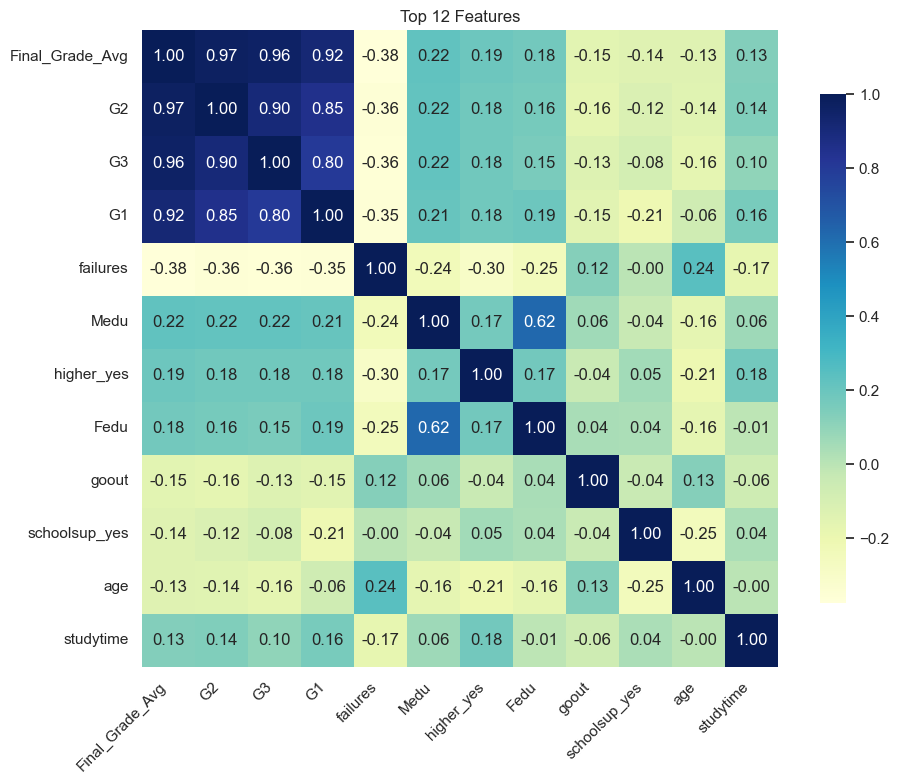

In [30]:
plot_source = corr_matrix_all.copy()
top_labels = (
        plot_source["Final_Grade_Avg"]
        .abs()
        .sort_values(ascending=False)
        .head(12)
        .index
        .tolist()
    )
plot_matrix = plot_source.loc[top_labels, top_labels]
plot_title = "Top 12 Features"

plt.figure(figsize=(10, 8))
sns.heatmap(plot_matrix, annot=True, cmap="YlGnBu", fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title(plot_title)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

For this one, I tried to congest it to the top 12 features to see which ones are most correlated. It became more digestible but still not enough for a good storytelling.

In [72]:
corr_cols = ["Medu", "Fedu", "internet_yes", "studytime", "failures", "absences", "Final_Grade_Avg"]
available_corr_cols = [c for c in corr_cols if c in encoded_df.columns]
corr_matrix = encoded_df[available_corr_cols].corr(numeric_only=True)
print("Correlation matrix preview:")
display(corr_matrix)

Correlation matrix preview:


,Medu,Fedu,internet_yes,studytime,failures,absences,Final_Grade_Avg
Medu,1.000000,0.623455,0.201463,0.064944,-0.236680,0.100285,0.224260
Fedu,0.623455,1.000000,0.127507,-0.009175,-0.250408,0.024473,0.175852
internet_yes,0.201463,0.127507,1.000000,0.059422,-0.063451,0.101701,0.102628
studytime,0.064944,-0.009175,0.059422,1.000000,-0.173563,-0.062700,0.134565
failures,-0.236680,-0.250408,-0.063451,-0.173563,1.000000,0.063726,-0.375759
absences,0.100285,0.024473,0.101701,-0.062700,0.063726,1.000000,-0.005909
Final_Grade_Avg,0.224260,0.175852,0.102628,0.134565,-0.375759,-0.005909,1.000000


I read the actual dataset and picked the social and economical factors that can affect the final average.

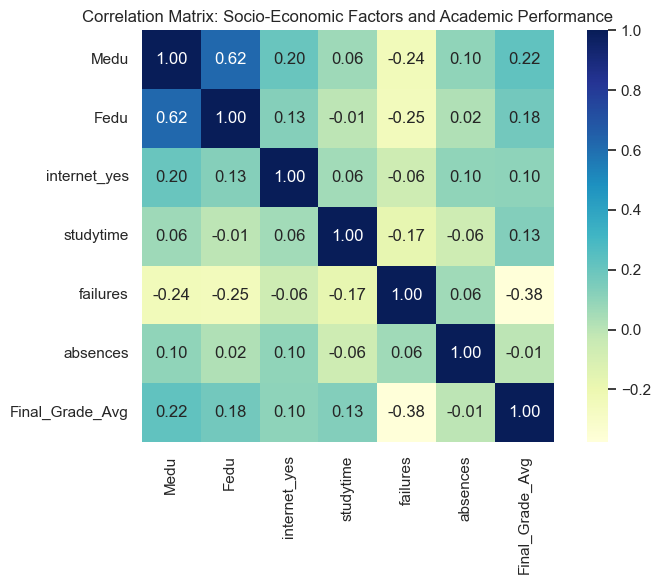

In [73]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", square=True)
plt.title("Correlation Matrix: Socio-Economic Factors and Academic Performance")
plt.tight_layout()
plt.show()

Visualized the above table so the viewers can easily generate insights without looking at numbers. What I noticed is that a student's parent's education are the most correlated, which does not matter for this storytelling but shows that someone would more likely want to find a partner with the same or at least close to their academic level. Moreover, the parent's education level are most likely to affect a student's performance positively in school, though with low correlation. Availability of internet and study time also affects the students' performance. 

Evidently, failures affect the final average negatively. Absences, although close to 0 correlation to the final average, shows a small positive correlation to failure and also small negative correlation to study time, which can say that less study time shows that a student has less interest in studying, leading to absences, and eventually, failure.

In [84]:
threshold = 10
viz_df = raw_df.copy()
viz_df["Final_Grade_Avg"] = viz_df[["G1", "G2", "G3"]].mean(axis=1)
viz_df["Proficiency"] = viz_df["G3"].ge(threshold).map({True: "Meets Minimum Proficiency", False: "Below Proficiency"})

support_plot = (
    viz_df.groupby(["Proficiency", "famsup", "schoolsup"]).size().reset_index(name="count")
)

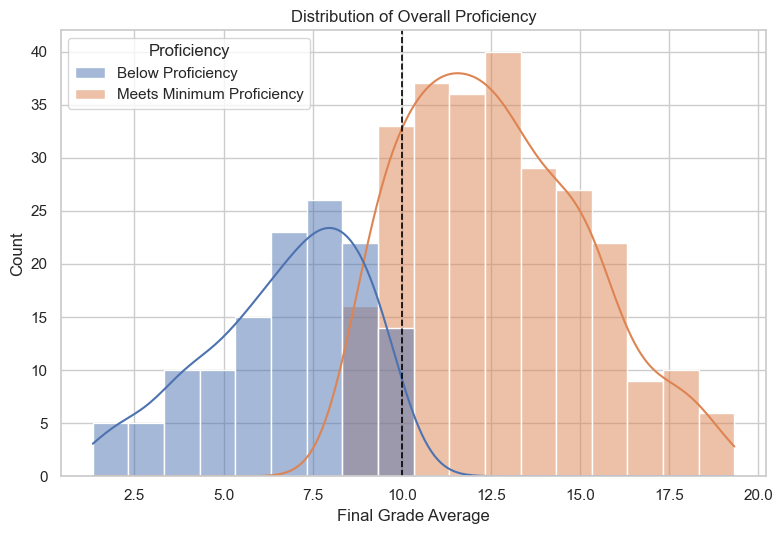

In [76]:
plt.figure(figsize=(8, 5.5))
sns.histplot(data=viz_df, x="Final_Grade_Avg", hue="Proficiency", kde=True, bins=18)
plt.axvline(10, color="black", linestyle="--", linewidth=1.2)
plt.title("Distribution of Overall Proficiency")
plt.xlabel("Final Grade Average")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

For this graph, I used the average grade for the x values but just the G3 grade for the bins, this is to show that even though the average grade of a student shows that they are below proficiency, their G3 grade can say otherwise. Assuming that the G3 exam covers the topics from first period to the final period, this means that a percentage of the students are slow learners, where they need time to absorb the topics and can't be evaluated on the first or second periods immediately.

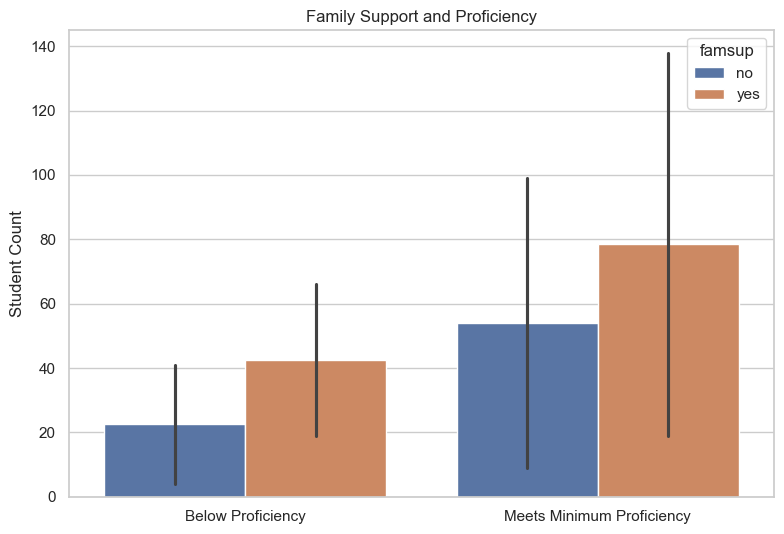

In [85]:
plt.figure(figsize=(8, 5.5))
sns.barplot(data=support_plot, x="Proficiency", y="count", hue="famsup")
plt.title("Family Support and Proficiency")
plt.xlabel("")
plt.ylabel("Student Count")
plt.tight_layout()
plt.show()

For this graph, I used proficiency status on the x-axis and student count on the y-axis, with family support as the colored bars. This is to show that even though family support is not the only factor affecting performance, students who have support at home tend to appear more often in the group that meets minimum proficiency. At the same time, the graph also shows that some students without family support still reach proficiency, which means family support helps, but it does not fully determine success. This suggests that student achievement depends on a mix of support, effort, and study habits, not just one background factor.

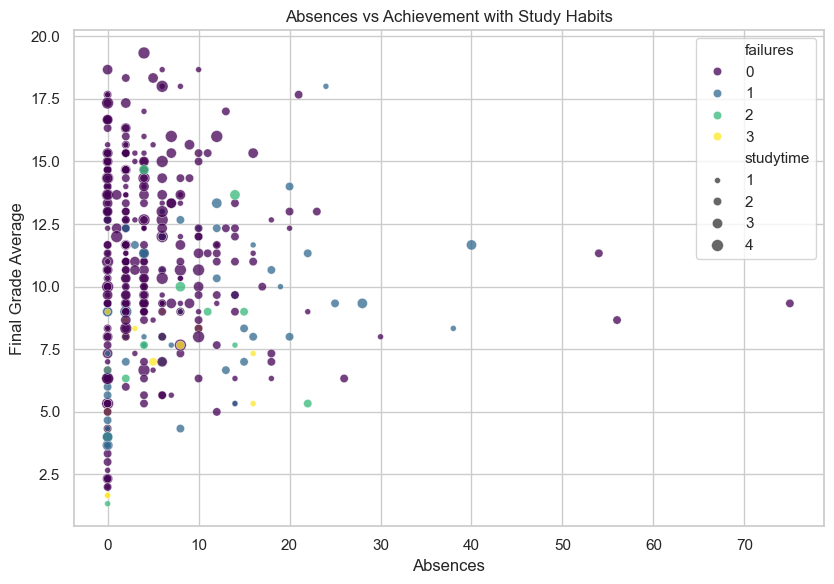

In [86]:
plt.figure(figsize=(8.5, 6))
sns.scatterplot(
    data=viz_df,
    x="absences",
    y="Final_Grade_Avg",
    hue="failures",
    size="studytime",
    palette="viridis",
    alpha=0.75,
)
plt.title("Absences vs Achievement with Study Habits")
plt.xlabel("Absences")
plt.ylabel("Final Grade Average")
plt.tight_layout()
plt.show()

In this scatter plot, absences are assigned on the x values and final average grade on the y values, with failures and studytime added for context. This shows that students with lower absences usually cluster at stronger grades, while high absence cases are more scattered and often weaker. It suggests that attendance matters, but its effect is even clearer when combined with repeated failures and limited study time.

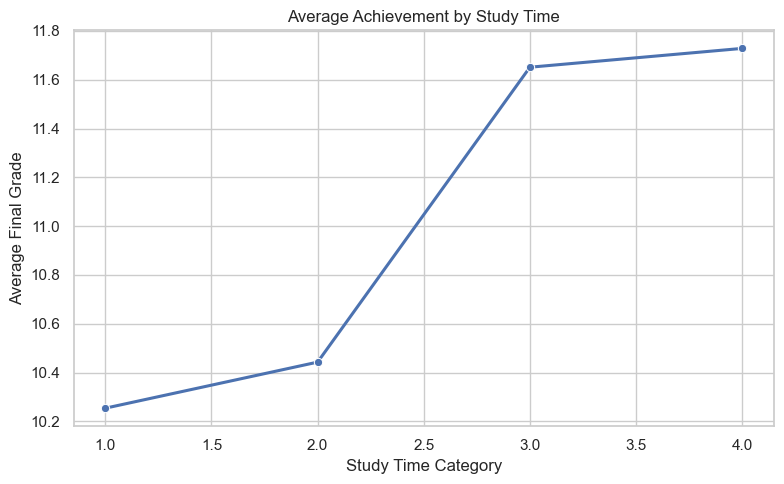

In [90]:
study_summary = viz_df.groupby("studytime")["Final_Grade_Avg"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=study_summary, x="studytime", y="Final_Grade_Avg", marker="o", linewidth=2.2)
plt.title("Average Achievement by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.tight_layout()
plt.show()

For this graph, I used study time categories on the x values and the average final grade on the y values. This shows a clear upward pattern, where students who spend more time studying tend to achieve higher grades overall. It suggests that consistent study habits are one of the strongest student behaviors linked to better academic performance.

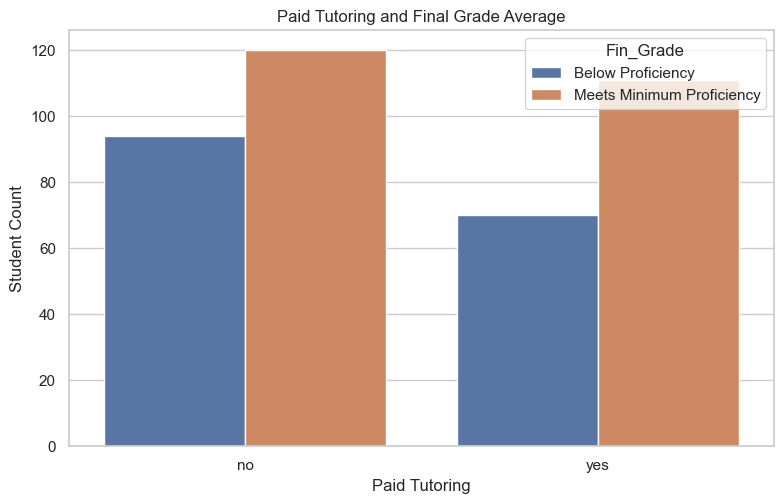

In [ ]:
viz_df["Fin_Grade"] = viz_df["Final_Grade_Avg"].ge(threshold).map({True: "Meets Minimum Proficiency", False: "Below Proficiency"}) 
avg_plot = (
    viz_df.groupby(["paid", "Fin_Grade"]).size().reset_index(name="count")
)

plt.figure(figsize=(8, 5.2))
sns.barplot(data=avg_plot, x="paid", y="count", hue="Fin_Grade")
plt.title("Paid Tutoring and Final Grade Average")
plt.xlabel("Paid Tutoring")
plt.ylabel("Student Count")
plt.tight_layout()
plt.show()

This graph shows the proficiency of the students in the final grade average in relation to them getting paid tutoring or not. It shows that students appear in the "Meets Minimum Proficiency" group when they get paid tutoring, however, many students still pass without tutoring. This suggests that extra academic help can support achievement, but it is not the only factor driving performance. 

Note: I used the same categories as the proficiency for the G3 that I used before (Below Proficiency, Meets Minimum Proficiency) but this is for the final average instead of just the final G3 grade.

## Conclusion

Across the visualizations, the strongest pattern is that academic success is linked to a combination of factors rather than one single cause. Students who study more tend to perform better, while absences and repeated failures are associated with weaker outcomes. Support at home and paid tutoring all help improve performance, but they do not guarantee success on their own. Overall, the visualizations suggest that quality education depends on consistent study habits, regular attendance, and access to learning support both inside and outside the classroom.